# Letter recognition (small size)

> Indeed, I once even proposed that the toughest challenge facing AI workers is to answer the question: “What are the letters ‘A’ and ‘I’? - [Douglas R. Hofstadter](https://web.stanford.edu/group/SHR/4-2/text/hofstadter.html) (1995)


## notMNIST


Data source: [notMNIST](http://yaroslavvb.blogspot.com/2011/09/notmnist-dataset.html) (you need to download `notMNIST_small.mat` file):

![](http://yaroslavvb.com/upload/notMNIST/nmn.png)

> some publicly available fonts and extracted glyphs from them to make a dataset similar to MNIST. There are 10 classes, with letters A-J taken from different fonts.

> Approaching 0.5% error rate on notMNIST_small would be very impressive. If you run your algorithm on this dataset, please let me know your results.


## So, why not MNIST?

Many introductions to image classification with deep learning start with MNIST, a standard dataset of handwritten digits. This is unfortunate. Not only does it not produce a “Wow!” effect or show where deep learning shines, but it also can be solved with shallow machine learning techniques. In this case, plain k-Nearest Neighbors produces more than 97% accuracy (or even 99.5% with some data preprocessing!). Moreover, MNIST is not a typical image dataset – and mastering it is unlikely to teach you transferable skills that would be useful for other classification problems

> Many good ideas will not work well on MNIST (e.g. batch norm). Inversely many bad ideas may work on MNIST and no[t] transfer to real [computer vision]. - [François Chollet’s tweet](https://twitter.com/fchollet/status/852594987527045120)

In [1]:
!wget http://yaroslavvb.com/upload/notMNIST/notMNIST_small.mat

--2022-09-20 05:08:45--  http://yaroslavvb.com/upload/notMNIST/notMNIST_small.mat
Resolving yaroslavvb.com (yaroslavvb.com)... 129.121.4.193
Connecting to yaroslavvb.com (yaroslavvb.com)|129.121.4.193|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 117586976 (112M)
Saving to: ‘notMNIST_small.mat’

notMNIST_small.mat  100%[===================>] 112.14M  21.0MB/s    in 6.1s    

2022-09-20 05:08:51 (18.3 MB/s) - ‘notMNIST_small.mat’ saved [117586976/117586976]



In [2]:
import matplotlib.pyplot as plt
from scipy import io
import numpy as np
from sklearn.model_selection import train_test_split

## Data Loading

In [14]:
data = io.loadmat("notMNIST_small.mat")

# transform data
X = data['images']
y = data['labels']
resolution = 28
classes = 10

X = np.transpose(X, (2, 0, 1))

y = y.astype('int32')
X = X.astype('float32') 

# shape: (sample, x, y, channel)
X = X.reshape((-1, resolution, resolution, 1))

6437


Text(0.5, 1.0, 'A')

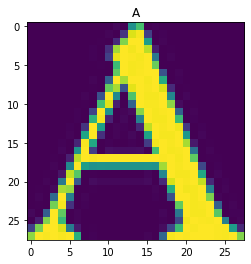

In [16]:
# looking at data; some fonts are strange
i = np.random.randint(0, 18723)
print(i)
plt.imshow( X[i,:,:,0] )
plt.title( "ABCDEFGHIJ"[y[i]] )

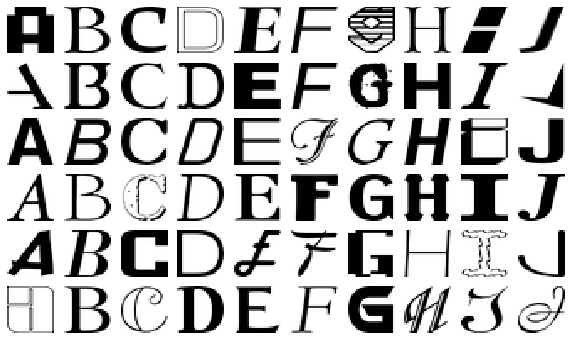

In [18]:
# random letters
rows = 6
fig, axs = plt.subplots(rows, classes, figsize=(classes, rows))

for letter_id in range(10):
    letters = X[y == letter_id]
    for i in range(rows):
        ax = axs[i, letter_id]
        ax.imshow(letters[np.random.randint(len(letters)),:,:,0],
                  cmap='Greys', interpolation='none')
        ax.axis('off')

In [19]:
# splitting data into training and test sets
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2022)

In [20]:
x_train.shape, y_train.shape

((14979, 28, 28, 1), (14979,))

## X : Min-Max Scaling

In [21]:
max_n,min_n=x_train.max(),x_train.min()
x_train=(x_train-min_n)/(max_n-min_n)
x_test=(x_test-min_n)/(max_n-min_n)

In [22]:
x_train.max(),x_train.min()

(1.0, 0.0)

## Y : One-Hot Encoding

In [23]:
from tensorflow.keras.utils import to_categorical

In [24]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int32)

In [25]:
y_train=to_categorical(y_train,10)
y_test=to_categorical(y_test,10)

## Keras로 자유롭게 CNN 모델링

1. [이 구조를 미니 버전으로 활용해봐도 좋다](https://img1.daumcdn.net/thumb/R800x0/?scode=mtistory2&fname=https%3A%2F%2Ft1.daumcdn.net%2Fcfile%2Ftistory%2F99DFA5415B38AC752E)
2. DropOut, BatchNormalization 등의 기능도 같이 활용해보자.

In [27]:
x_train.shape

(14979, 28, 28, 1)

In [26]:
from tensorflow import keras

In [47]:
keras.backend.clear_session()

il=keras.layers.Input((28,28,1))

hl=keras.layers.Conv2D(filters=64,kernel_size=(3,3),activation='relu',padding='same',strides=(1,1))(il)
hl=keras.layers.Conv2D(filters=64,kernel_size=(3,3),activation='relu',padding='same',strides=(1,1))(hl)
pl=keras.layers.MaxPool2D(pool_size=(2,2),strides=(2,2))(hl)
hl=keras.layers.BatchNormalization()(pl)
hl=keras.layers.Dropout(0.25)(hl)

hl=keras.layers.Conv2D(filters=128,kernel_size=(3,3),activation='relu',padding='same',strides=(1,1))(hl)
hl=keras.layers.Conv2D(filters=128,kernel_size=(3,3),activation='relu',padding='same',strides=(1,1))(hl)
pl=keras.layers.MaxPool2D(pool_size=(2,2),strides=(2,2))(hl)
hl=keras.layers.BatchNormalization()(pl)
hl=keras.layers.Dropout(0.25)(hl)

hl=keras.layers.Conv2D(filters=256,kernel_size=(3,3),activation='relu',padding='same',strides=(1,1))(hl)
hl=keras.layers.Conv2D(filters=256,kernel_size=(3,3),activation='relu',padding='same',strides=(1,1))(hl)
hl=keras.layers.Conv2D(filters=256,kernel_size=(3,3),activation='relu',padding='same',strides=(1,1))(hl)
pl=keras.layers.MaxPool2D(pool_size=(2,2),strides=(2,2))(hl)
hl=keras.layers.BatchNormalization()(pl)
hl=keras.layers.Dropout(0.25)(hl)

fl=keras.layers.Flatten()(hl)
hl=keras.layers.Dense(1024,activation='relu')(fl)
hl=keras.layers.Dense(1024,activation='relu')(hl)
hl=keras.layers.Dense(1024,activation='relu')(hl)
ol=keras.layers.Dense(10,activation='softmax')(hl)

model=keras.models.Model(inputs=il,outputs=ol)
model.compile(loss=keras.losses.categorical_crossentropy,optimizer=keras.optimizers.Adam(),metrics=['accuracy'])
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d (Conv2D)             (None, 28, 28, 64)        640       
                                                                 
 conv2d_1 (Conv2D)           (None, 28, 28, 64)        36928     
                                                                 
 max_pooling2d (MaxPooling2D  (None, 14, 14, 64)       0         
 )                                                               
                                                                 
 batch_normalization (BatchN  (None, 14, 14, 64)       256       
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 14, 14, 64)        0     

## Early Stopping을 이용한 학습

1. validation_split = 0.2
2. 1 epoch 돌려가며 빠르게 학습되는 batch_size를 찾을 것
3. 5 epoch 전보다 val_loss가 개선되지 않았으면 멈추는 얼리스토핑

In [31]:
from tensorflow.keras.callbacks import EarlyStopping

In [49]:
es=EarlyStopping(monitor='val_loss',patience=4,restore_best_weights=True,min_delta=0)

In [51]:
model.fit(x_train,y_train,verbose=1,epochs=10,callbacks=[es],batch_size=256)

Epoch 1/10
58/59 [============================>.] - ETA: 0s - loss: 0.0210 - Accuracy: 0.9939

59/59 [==============================] - 3s 56ms/step - loss: 0.0211 - Accuracy: 0.9937
Epoch 2/10
58/59 [============================>.] - ETA: 0s - loss: 0.0148 - Accuracy: 0.9952

59/59 [==============================] - 3s 56ms/step - loss: 0.0160 - Accuracy: 0.9951
Epoch 3/10
58/59 [============================>.] - ETA: 0s - loss: 0.0203 - Accuracy: 0.9937

59/59 [==============================] - 3s 56ms/step - loss: 0.0201 - Accuracy: 0.9938
Epoch 4/10
58/59 [============================>.] - ETA: 0s - loss: 0.0318 - Accuracy: 0.9906

59/59 [==============================] - 3s 58ms/step - loss: 0.0318 - Accuracy: 0.9906
Epoch 5/10
58/59 [============================>.] - ETA: 0s - loss: 0.0233 - Accuracy: 0.9921

...

59/59 [==============================] - 4s 60ms/step - loss: 0.0209 - Accuracy: 0.9936
Epoch 7/10
58/59 [============================>.] - ETA: 0s - loss: 0.0275 - Accuracy: 0.9912

59/59 [==============================] - 4s 60ms/step - loss: 0.0275 - Accuracy: 0.9911
Epoch 8/10
58/59 [============================>.] - ETA: 0s - loss: 0.0211 - Accuracy: 0.9934

59/59 [==============================] - 4s 61ms/step - loss: 0.0210 - Accuracy: 0.9935
Epoch 9/10
58/59 [============================>.] - ETA: 0s - loss: 0.0207 - Accuracy: 0.9938

59/59 [==============================] - 4s 61ms/step - loss: 0.0206 - Accuracy: 0.9938
Epoch 10/10
58/59 [============================>.] - ETA: 0s - loss: 0.0218 - Accuracy: 0.9932

59/59 [==============================] - 4s 60ms/step - loss: 0.0217 - Accuracy: 0.9932


* 예측값 생성

In [52]:
y_pred = model.predict(x_test)

* 생성한 예측값을 y_test 구조와 같게 만든다

In [53]:
pred_array = np.zeros(shape=(y_pred.shape[0], y_pred.shape[1]))
idx = 0

for arr_val in y_pred :
    # print(arr_val)
    pred_array[idx][arr_val.argmax()] = 1
    idx += 1

In [54]:
pred_array.shape

(3745, 10)

* 성능 평가

In [55]:
from sklearn.metrics import accuracy_score

In [56]:
print( f'{accuracy_score(y_test, pred_array):.4f}' )

0.9586


## 문자 이미지 시각화

In [57]:
import random as rd

In [58]:
character = {0:'A', 1:'B', 2:'C', 3:'D', 4:'E', 5:'F', 6:'G', 7:'H', 8:'I', 9:'J'}

* 실제 성능 확인을 위해 반복 실행!

id = 2697
실제 문자 : G
모델의 문자 예측 : G
모델의 문자별 예측 확률 : [  0.   0.   0.   0.   0.   0. 100.   0.   0.   0.]
정답


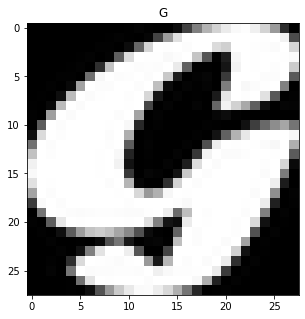

In [59]:
rand_n = rd.randrange(0, 3744)

print(f'id = {rand_n}')
print(f'실제 문자 : {character[y_test[rand_n].argmax()]}')
print(f'모델의 문자 예측 : {character[y_pred[rand_n].argmax()]}' )
print(f'모델의 문자별 예측 확률 : {np.round(y_pred[rand_n]*100)}')
# print(f'모델의 문자들 총 확률 : {sum(np.round(y_pred[rand_n]*100))}')

print('====================================================')

if y_test[rand_n].argmax() == y_pred[rand_n].argmax() :
    print('정답')
else :
    print('오답')

print('====================================================')

plt.figure(figsize=(5,5))
plt.imshow(x_test[rand_n].reshape(28, 28), cmap='gray')
plt.title("ABCDEFGHIJ"[y_test[rand_n].argmax()] )
plt.show()

* 틀린 문자만 확인해봅시다!

id = 2785
실제 문자 : D
모델의 문자 예측 : I
모델의 문자별 예측 확률 : [ 0.  0.  0. 35.  0.  0.  0.  0. 64.  0.]
오답


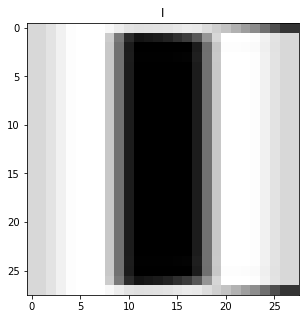

In [60]:
t_f = ( y_test.argmax(axis=1) == y_pred.argmax(axis=1) )
false_id = np.where(t_f==False)[0]
false_n = len(false_id)

id = false_id[rd.randrange(0, false_n)]

print(f'id = {id}')
print(f'실제 문자 : {character[y_test[id].argmax()]}')
print(f'모델의 문자 예측 : {character[y_pred[id].argmax()]}' )
print(f'모델의 문자별 예측 확률 : {np.round(y_pred[id]*100)}')
# print(f'모델의 문자들 총 확률 : {sum(np.round(y_pred[rand_n]*100))}')

print('====================================================')

if y_test[id].argmax() == y_pred[id].argmax() :
    print('정답')
else :
    print('오답')

print('====================================================')

plt.figure(figsize=(5,5))
plt.imshow(x_test[id].reshape(28, 28), cmap='gray')
plt.title("ABCDEFGHIJ"[y_pred[id].argmax()] )
plt.show()